<a href="https://colab.research.google.com/github/bharath-0905/mlproject/blob/main/marking_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['KAGGLE_USERNAME']="Bharath20"
os.environ['kaggle_key']="KGAT_10c8f629b88da2dac16c940f033b02cc"

In [ ]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
100% 39.3k/39.3k [00:00<00:00, 1.20MB/s]



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [10]:
# Step 1: Import Library
import pandas as pd

# Step 2: Load Dataset
df = pd.read_csv("/content/marketing_data.csv")

# Step 3: Display first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,Spain


In [ ]:
# Remove extra spaces in column names
df.columns = df.columns.str.strip()

In [ ]:
# Display Dataset
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nMissing Values")
print(df.isnull().sum())


      ID  Year_Birth   Education Marital_Status   Income   Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced   84835.0        0         0   
1      1        1961  Graduation         Single   57091.0        0         0   
2  10476        1958  Graduation        Married   67267.0        0         1   
3   1386        1967  Graduation       Together   32474.0        1         1   
4   5371        1989  Graduation         Single   21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumStorePurchases  NumWebVisitsMonth  \
0  2014-06-16        0       189  ...                  6                  1   
1  2014-06-15        0       464  ...                  7                  5   
2  2014-05-13        0       134  ...                  5                  2   
3  2014-05-11        0        10  ...                  2                  7   
4  2014-04-08        0         6  ...                  2                  7   

   AcceptedCmp3  AcceptedCmp4  AcceptedCmp5 

In [ ]:
# Fill Missing Values

for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.columns = df.columns.str.strip()
# Select Features
X = df[['Income',
        'Recency',
        'MntWines',
        'MntFruits',
        'MntMeatProducts',
        'MntFishProducts',
        'MntSweetProducts',
        'MntGoldProds',
        'NumDealsPurchases',
        'NumWebPurchases',
        'NumCatalogPurchases',
        'NumStorePurchases',
        'NumWebVisitsMonth']]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# DBSCAN Model
dbscan = DBSCAN(eps=0.8, min_samples=8)
clusters = dbscan.fit_predict(X_scaled)

In [ ]:
# Add Cluster Labels
df["Cluster"] = clusters

In [ ]:
# Number of Clusters
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print("\nNumber of Clusters:", n_clusters)


Number of Clusters: 2


In [ ]:
# Noise Points
noise = list(clusters).count(-1)
print("Noise Points:", noise)

Noise Points: 1469


In [ ]:
# Silhouette Score
if n_clusters > 1:
    score = silhouette_score(X_scaled, clusters)
    print("Silhouette Score:", score)

Silhouette Score: 0.03225223199551857


In [ ]:
# Cluster Count
print("\nCluster Counts")
print(df["Cluster"].value_counts())


Cluster Counts
Cluster
-1    1469
 0     765
 1       6
Name: count, dtype: int64


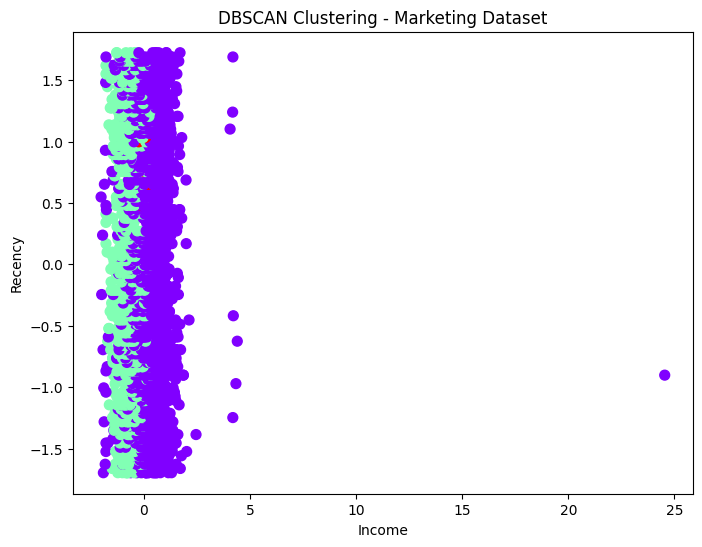

In [ ]:
# Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='rainbow',
    s=50
)
plt.title("DBSCAN Clustering - Marketing Dataset")
plt.xlabel("Income")
plt.ylabel("Recency")
plt.show()

In [ ]:
# Save Output
df.to_csv("Marketing_DBSCAN_Output.csv", index=False)
print("\nDBSCAN Clustering Completed Successfully.")


DBSCAN Clustering Completed Successfully.
